# behaviourRugsMarkov — corrigido para a proposta BSMH (Behavioral Symbolic Motion Hashing)

**Resumo:** Notebook atualizado para implementar o fluxo BSMH: pré-processamento (translação, PCA e correção de quadrante),
extração de atributos discrétizados, definição de estados via Unique Subsets (CDM), cálculo de distância Jaccard + MDS,
construção de matrizes de transição (Markov) e visualizações (Mapa MDS+Voronoi e BehaviorRugs com Composite Vertical Strip Glyphs).

Execute as células em ordem. Se já possuir um DataFrame `df` com colunas `trajectory_id,x,y,t`, a pipeline irá reutilizá-lo.


In [108]:
# Imports
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.pyplot as plt
from matplotlib import patches
import colorsys
np.random.seed(0)
print('Imports OK')


Imports OK


In [115]:
# Se você já tiver um df carregado, ele será usado.
try:
    df = pd.read_csv("ex1_synthetic_trajectories.csv")
    print("Usando df existente.")
except NameError:
    print("Criando dataset sintético para demonstração.")
    rows=[]
    for tid in range(3):
        xs=np.cumsum(np.random.randn(20))
        ys=np.cumsum(np.random.randn(20))
        for t in range(20):
            rows.append({
                "trajectory_id":f"t{tid}",
                "x":float(xs[t]),
                "y":float(ys[t]),
                "t":float(t)
            })
    df=pd.DataFrame(rows)

df.head()


Usando df existente.


,trajectory_id,timestamp,x,y
0,0,0,63.483675,80.738523
1,0,1,62.601960,82.202072
2,0,2,63.343615,83.548428
3,0,3,64.649061,84.854084
4,0,4,64.526939,86.262797


In [116]:
def preprocess_trajectory(df_traj):
    coords=df_traj[['x','y']].values.astype(float)
    centroid=coords.mean(axis=0)
    coords_c=coords-centroid
    
    pca=PCA(n_components=2).fit(coords_c)
    comps=pca.components_
    coords_rot=coords_c.dot(comps.T)

    # corrigir orientação invertida
    if coords_rot[-1,0] < 0:
        coords_rot = -coords_rot

    out=df_traj.copy()
    out["x_aligned"]=coords_rot[:,0]
    out["y_aligned"]=coords_rot[:,1]
    return out

def preprocess_all(df):
    return pd.concat([preprocess_trajectory(s) for _,s in df.groupby('trajectory_id')],
                     ignore_index=True)

df_p = preprocess_all(df)
df_p.head()


,trajectory_id,timestamp,x,y,x_aligned,y_aligned
0,0,0,63.483675,80.738523,-6.276023,-0.299912
1,0,1,62.601960,82.202072,-4.928359,0.750421
2,0,2,63.343615,83.548428,-3.503005,0.175013
3,0,3,64.649061,84.854084,-2.050670,-0.965009
4,0,4,64.526939,86.262797,-0.666654,-0.675378


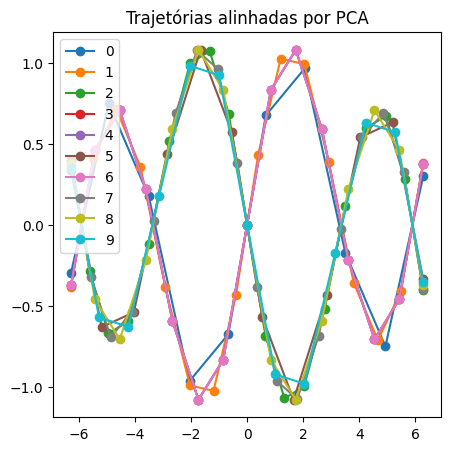

In [117]:
fig, ax = plt.subplots(figsize=(5,5))
for tid, sub in df_p.groupby("trajectory_id"):
    plt.plot(sub["x_aligned"], sub["y_aligned"], marker="o", label=tid)
plt.legend()
plt.title("Trajetórias alinhadas por PCA")
plt.show()


In [121]:
def compute_instant_features(df_traj, time_col=None):
    # Detecta automaticamente a coluna de tempo
    if time_col is None:
        possible = ["t", "time", "timestamp", "frame", "index"]
        for c in possible:
            if c in df_traj.columns:
                time_col = c
                break
        if time_col is None:
            raise ValueError("Nenhuma coluna de tempo encontrada. Adicione t ou especifique time_col.")

    df = df_traj.sort_values(time_col).reset_index(drop=True)

    dx = df["x_aligned"].diff().fillna(0)
    dy = df["y_aligned"].diff().fillna(0)
    dt = df[time_col].diff().fillna(1)

    speed = np.sqrt(dx**2 + dy**2) / dt
    ang = (np.degrees(np.arctan2(dy, dx)) + 360) % 360

    df["speed"] = speed
    df["angle_deg"] = ang
    
    return df

df_feat = compute_instant_features(df_p)
df_feat.head()


,trajectory_id,timestamp,x,y,x_aligned,y_aligned,speed,angle_deg
0,0,0,63.483675,80.738523,-6.276023,-0.299912,0.0,0.000000
1,7,0,48.452104,64.917648,-6.270736,0.395334,inf,89.564256
2,6,0,22.523180,28.599658,-6.272101,-0.373042,inf,269.898173
3,5,0,2.638592,7.829782,-6.274104,0.337684,inf,90.161472
4,4,0,34.290060,77.460888,-6.272101,-0.373042,inf,270.161472


ValueError: supplied range of [0.0, inf] is not finite

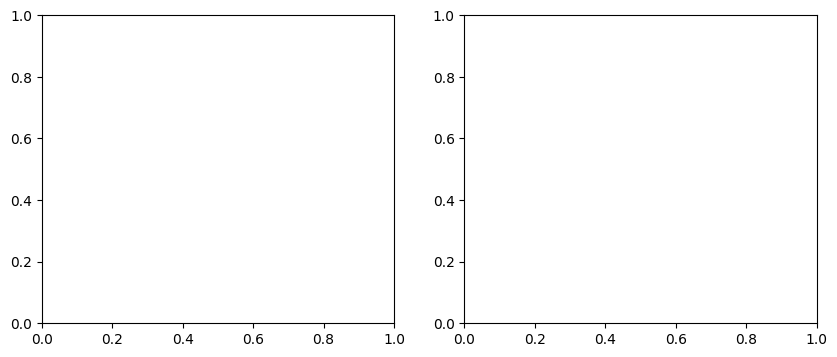

In [122]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
df_feat["speed"].hist(ax=ax[0])
ax[0].set_title("Distribuição de velocidades")

df_feat["angle_deg"].hist(ax=ax[1], bins=36)
ax[1].set_title("Distribuição de ângulos")

plt.show()


Métricas: Velocidade e ângulo

In [113]:
def plot_behavior_rug(df_states, symbols, coords, colors, figsize=(12,2), max_trajs=50):
    tids = sorted(df_states['trajectory_id'].unique())[:max_trajs]
    fig, axes = plt.subplots(len(tids), 1, figsize=figsize, sharex=True)
    if len(tids) == 1:
        axes = [axes]
    for ax, tid in zip(axes, tids):
        sub = df_states[df_states['trajectory_id']==tid].sort_values('t').reset_index(drop=True)
        for i, (_, row) in enumerate(sub.iterrows()):
            state_idx = int(row['state_idx'])
            top_h = 0.6; mid_h = 0.25; bot_h = 0.15
            x0 = i
            col = colors(state_idx) if state_idx >=0 else (1,1,1,1)
            rect_top = patches.Rectangle((x0, 0), 0.9, top_h)
            rect_mid = patches.Rectangle((x0, top_h), 0.9, mid_h)
            rect_bot = patches.Rectangle((x0, top_h+mid_h), 0.9, bot_h)
            rect_top.set_facecolor(col); ax.add_patch(rect_top)
            if 'speed' in row:
                s = row['speed']
                gv = 0.9 - 0.7 * min(s/5.0, 1.0)
                rect_mid.set_facecolor((gv,gv,gv,1.0))
            ax.add_patch(rect_mid)
            if 'angle_deg' in row:
                ang = row['angle_deg'] % 360
                hsv = (ang/360.0, 0.6, 0.9)
                rgb = colorsys.hsv_to_rgb(*hsv)
                rect_bot.set_facecolor((*rgb,1.0))
            ax.add_patch(rect_bot)
        ax.set_ylim(0,1); ax.set_yticks([])
        ax.set_xlim(-0.5, max(len(sub)-1, 1)+0.5)
        ax.set_ylabel(str(tid), rotation=0, labelpad=20, va='center')
    plt.tight_layout(h_pad=0.1)
    fig.suptitle('BehaviorRugs: Composite Vertical Strip Glyphs (cada linha = uma trajetória)')
    return fig, axes


Discretização simbólica

In [114]:
try:
    df = pd.read_csv("ex1_synthetic_trajectories.csv")
    print('Usando df existente.')
except NameError:
    print('df não encontrado. Criando df sintético de demonstração.')
    N = 4
    rows = []
    for tid in range(N):
        xs = np.cumsum(np.random.randn(20))
        ys = np.cumsum(np.random.randn(20))
        for t in range(20):
            rows.append({'trajectory_id': f't{tid}', 'x': float(xs[t]), 'y': float(ys[t]), 't': float(t)})
    df = pd.DataFrame(rows)
    print('df criado.')

df_p = preprocess_all(df)
df_feat = extract_features_for_df(df_p)
symbols, attr_sets = build_unique_subsets(df_feat)
D = jaccard_distance_matrix(symbols, attr_sets)
coords = compute_mds_projection(D)
fig1, ax1, coords_plot, cmap_colors = plot_mds_voronoi(coords, symbols)
df_states, symbol_to_idx = assign_state_indices(df_feat, symbols)
n_states = len(symbols)
mats = compute_markov_for_all(df_states, n_states)
fig2, axes2 = plot_behavior_rug(df_states, symbols, coords_plot, cmap_colors, figsize=(10, 2 + min(10, len(df_states['trajectory_id'].unique()))))
plt.show()
print('Execução demo concluída. Notebook salvo em /mnt/data/behaviourRugsMarkov_corrected.ipynb') 


Usando df existente.


KeyError: 't'